# Forecast

เป้าหมายคือ ใช้ข้อมูลเสาปีที่มี (2024) ทำนายปีถัดไป (2025) แล้วเทียบกับข้อมูลเสาจริงเมื่อได้ไฟล์มา

## CELL 1 - ตั้งไซต์

In [1]:
import os
os.environ["UWIN_SITE"] = "013054"

## CELL 2 - import + ค่าที่ต้องแก้ก่อนรัน

- ACTUAL_FILE : ชื่อไฟล์เสาปีที่ทำนาย ถ้ายังไม่มีให้เป็น None จะข้ามการเทียบผล
- START, END : ช่วงเวลาที่ทำนาย
- REUSE_MODEL : stamp Model Stage 4 ใช้เติมช่องว่าง WS160 ของ Raw Data ตอนเทียบผล

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from uwinControl import config, data_io, energy, features, forecast, models, qc, reference

def show(title, **kv):
    print(f"[{title}] " + " | ".join(f"{key} = {value}" for key, value in kv.items()))

SITE = config.get_site()
TARGET = f"WS{SITE['mast_height_m']}"
HUB_HEIGHT = SITE['hub_height_m']

TRAIN_FILE = SITE['raw_filename'] # Raw Data 2024
ACTUAL_FILE = "wind_raws_2025.csv" # ใส่ชื่อไฟล์ของปี 2025
START, END = "2025-01-01", "2025-12-31 23:50"
HEIGHTS = (100, 120, 140, 150, 160, 170, 180) # ความสูงที่จะคิดพลังงาน ต้องมี hub height อยู่ด้วย
REUSE_MODEL = None # stamp โมเดล Stage 4 ใช้เติมช่องว่าง WS160 ของข้อมูลจริงตอนเทียบผล

assert not config.validate_site()

I0000 00:00:1789631782.600081   51305 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789631783.477340   51305 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789631787.719008   51305 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## CELL 3 - Load Data + QC + ERA5

ใช้ข้อมูลลม WS160 ที่ทำการวัดจริง ยกไปเป็น hub height ด้วย Power Law

In [ ]:
raw_data = data_io.load_raw_data(TRAIN_FILE)
clean_data = qc.run_qc(raw_data), print("")
era5_data = reference.load_era5()

DATA_VERSION = data_io.save_version(raw_data, note = "forecast train")
RUN_ID = data_io.start_run(note = f"FORECAST {START[:4]}", data_version = DATA_VERSION, era5_info = reference.era5_info(era5_data))

# ข้อมูลลมวัดจริงจากยอดเสา ยกไปเป็น hub height ด้วย Power Law
_, ALPHA = features.compute_alpha(features.build_features(clean_data))
HUB_FACTOR = (HUB_HEIGHT / SITE['mast_height_m']) ** ALPHA
wind = clean_data[TARGET] * HUB_FACTOR
AIR_DENSITY = energy.air_density(clean_data['Temp'].median(), clean_data['Pres'].median())

show(
    'TRAIN', 
    ช่วงเวลา = f"{wind.first_valid_index():%d %b %Y} - {wind.last_valid_index():%d %b %Y}",
    coverage = f"{wind.notna().mean()*100:.1f}%", 
    alpha = f"{ALPHA:.4f}", 
    hub_factor = f"{HUB_FACTOR:.4f}", 
    air_density = f"{AIR_DENSITY:.4f}"
    )

display(pd.DataFrame({
    "windspeed_mean": wind.resample("MS").mean(), 
    "coverage_pct": wind.notna().resample("MS").mean() * 100
    }).round(2).T)

ช่วง: 2024-01-01 00:00:00 ถึง 2024-12-31 23:50:00 (GMT+7)
แถวที่มี 50,646 จากแถวที่ควรมี 52,704 (coverage 96.10%)
แถวที่หายไป 2,058

QC SD: ตัดค่านอกช่วง [0.0, 5.0] ออก 5 แถว (0.01%)
QC Temp: ตัดค่านอกช่วง [5.0, 50.0] ออก 4,847 แถว (9.20%)
QC Pres: ตัดค่านอกช่วง [950.0, 1050.0] ออก 4,846 แถว (9.19%)
พิกัดที่ใช้ในการกริด: 16.000, 104.250 (พิกัดห่างจากไซต์ 2.9 กม.)
ช่วงเวลา: 2006-01-01 07:00:00 ถึงช่วง 2026-08-18 12:00:00 (เวลา Asia/Bangkok)
จำนวนแถว: 180,822
ลมเฉลี่ยที่ 100 ม.: 4.99 m/s

Run file: /home/jovyan/project/data/outputs/013054_20260917_075748
[TRAIN] ช่วง = 01 Jan 2024 - 31 Dec 2024 | coverage = 88.4% | alpha = 0.2241 | hub_factor = 0.9856 | air_density = 1.1521


timestamp,2024-01-01,2024-02-01,2024-03-01,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01
ws_mean,5.15,5.10,4.35,3.85,4.04,5.97,5.46,5.01,6.98,4.26,3.66,5.32
coverage_pct,96.59,96.55,100.00,100.00,99.89,98.08,99.98,99.98,99.86,99.93,26.39,43.64


## CELL 4 - fit + gate การแจกแจงข้อมูล

ตรวจค่าลมที่จำลอง ว่าเหมือนข้อมูลจริงไหม
- sd = ความแกว่งของข้อมูลที่จำลองมา (0.8 - 1.2)
- KS = ระยะห่างของการกระจายตัวข้อมูล (< 0.10) 
- Weibull k = การกระจายตัวของข้อมูลลม (ไม่เกิน 0.3)

In [ ]:
state = forecast.fit(wind, era5_data)

# gate: ลมที่จำลองต้องมีการแจกแจงเหมือนของจริง ถ้าไม่ผ่านห้ามใช้ต่อ
simulate = [forecast.simulate(state, wind.index.min(), wind.index.max(), seed = s) for s in range(10)]
real_data = wind.dropna()
sd_ratio = np.mean([s.std() for s in simulate]) / real_data.std()
ks_statistic = np.mean([stats.ks_2samp(s.dropna(), real_data).statistic for s in simulate])
k_real_data = energy.fit_weibull(real_data)[0]
k_simulate = energy.fit_weibull(simulate[0])[0]

show(
    'FIT', 
    level = config.FORECAST['level_source'], 
    interannual_variability = f"{state['interannual_variability']*100:.2f}%",
    sd_ratio = f"{sd_ratio:.3f}", 
    KS = f"{ks_statistic:.3f}", 
    k_real_data = f"{k_real_data:.3f}", 
    k_simulate = f"{k_simulate:.3f}")
assert 0.8 <= sd_ratio <= 1.2 and ks_statistic < 0.10 and abs(k_real_data - k_simulate) <= 0.3, "การแจกแจงไม่ผ่าน"

[FIT] level = site | interannual_variability = 4.01% | sd_ratio = 0.960 | KS = 0.050 | k_real = 2.228 | k_sim = 2.179


## CELL 5 - Predict

- forecast_10min.csv : Expectation + ex 1 line
- forecast_D/MS/YS.csv : ค่าสถิติลมและพลังงานแบบ P10/P50/P90 จาก ensemble

ค่ารายชั่วโมงถูกต้องเชิงสถิติ ไม่ถูกต้องราย timestamp

In [ ]:
point = forecast.expected(state, START, END) # ค่าคาดหวังราย 10 นาที (point forecast)
sample = forecast.simulate(state, START, END, seed = 0) # ตัวอย่าง 1 เส้นที่แกว่งเหมือนจริง
data_io.save_output(pd.DataFrame({"windspeed_expected": point, "windspeed_sample": sample}), "forecast_10min")

outputs = {}
for freq in ("D", "MS", "YS"):
    outputs[freq] = forecast.ensemble_stats(state, START, END, freq, air_density = AIR_DENSITY)
    data_io.save_output(outputs[freq], f"forecast_{freq}")

year = outputs["YS"].iloc[0]
show(
    f'FORECAST {START[:4]} @ {HUB_HEIGHT} m',
    ws_mean = f"{year['windspeed_mean_p50']:.2f} ({year['windspeed_mean_p10']:.2f}-{year['windspeed_mean_p90']:.2f}) m/s",
    ws_max = f"{year['windspeed_max_p50']:.1f} m/s",
    energy = f"{year['energy_mwh_p50']/1000:.1f} ({year['energy_mwh_p10']/1000:.1f}-{year['energy_mwh_p90']/1000:.1f}) GWh",
    CF = f"{year['capacity_factor_pct_p50']:.1f}%")
display(outputs["MS"][["windspeed_mean_p10", "windspeed_mean_p50", "windspeed_mean_p90", "windspeed_max_p50", "windspeed_sd_p50", "energy_mwh_p50"]].round(2))

Save: 013054_20260917_075748/forecast_10min.csv
Save: 013054_20260917_075748/forecast_D.csv
Save: 013054_20260917_075748/forecast_MS.csv
Save: 013054_20260917_075748/forecast_YS.csv
[FORECAST 2025 @ 150 m] ws_mean = 4.91 (4.59-5.20) m/s | ws_max = 19.7 m/s | energy = 34.5 (27.6-41.3) GWh | CF = 8.8%


,windspeed_mean_p10,windspeed_mean_p50,windspeed_mean_p90,windspeed_max_p50,windspeed_sd_p50,energy_mwh_p50
2025-01-01,4.36,5.05,5.86,12.07,2.16,2920.48
2025-02-01,4.16,4.94,5.78,11.48,2.04,2426.42
2025-03-01,3.93,4.30,4.73,9.58,1.71,1547.86
2025-04-01,3.61,3.85,4.11,9.26,1.55,987.44
2025-05-01,3.65,3.99,4.36,11.81,1.87,1421.94
2025-06-01,5.15,5.83,6.52,17.01,2.47,4483.19
2025-07-01,4.80,5.39,6.02,19.29,2.17,3396.92
2025-08-01,4.81,5.36,6.05,14.13,2.35,3588.54
2025-09-01,5.39,6.65,7.86,16.11,2.77,6621.03
2025-10-01,3.52,4.22,4.98,12.80,2.48,2359.48


## CELL 5B - File Forecast รูปแบบ Raw Data

- forecast_raws_<ปี>_seed0.csv คอลัมน์และ channel เหมือนไฟล์ Raw Data ทุกอย่าง (15 channel, avg/gust/gust_dir/max/min/sd)
- เป็น 1 ปีที่เป็นไปได้ (seed 0 เส้นเดียวกับ `windspeed_sample`) ไม่ใช่ P50 -> ค่า P10/P50/P90 ดูจาก forecast_MS/YS.csv
- round-trip: โหลดไฟล์กลับผ่าน load_raw_data -> run_qc ต้องได้ WS160 ตรงกับ ws_sample


In [ ]:
raw_forecast = forecast.to_raw(state, TRAIN_FILE, START, END, seed = 0)
RAW_FORECAST_FILE = data_io.run_dir() / f"forecast_raws_{START[:4]}_seed.csv" # ชื่อไฟล์
raw_forecast.to_csv(RAW_FORECAST_FILE, index = False)

show(
    'RAW FORECAST',
    ชื่อไฟล์ = RAW_FORECAST_FILE.name,
    จำนวนแถวข้อมูล = f"{len(raw_forecast):,}",
    channel_sensor = raw_forecast['channel'].nunique(),
    ช่วงเวลา = f"{raw_forecast['timestamp'].iloc[-1][:16]} - {raw_forecast['timestamp'].iloc[0][:16]}",
    )
display(raw_forecast.head(15))

# round-trip: ไฟล์พยากรณ์ต้องเข้าท่อเดิมได้ และ WS160 หลัง QC ต้องตรงกับ ws_sample
check_data = qc.run_qc(data_io.load_raw_data(str(RAW_FORECAST_FILE)))
back = check_data[TARGET] * HUB_FACTOR
month_diff = (back.resample("MS").mean() / sample.resample("MS").mean() - 1) * 100
show(
    'ROUND TRIP',
    ws_raw = f"{back.mean():.3f}",
    ws_sample = f"{sample.mean():.3f}",
    ต่างรายเดือนสูงสุด = f"{month_diff.abs().max():.2f}%",
    )
assert month_diff.abs().max() < 2, "File Raw Data Forecast ไม่ตรงกับ ws_sample"

[RAW FORECAST] ชื่อไฟล์ = forecast_raws_2025_seed0.csv | จํานวนแถวข้อมูล = 787,155 | channel_sensor = 15 | ช่วงเวลา = 2025-01-01 00:00 - 2025-12-31 23:50


,site_code,sensor_id,timestamp,channel,height,direction,unit,avg,gust,gust_dir,max,min,sd
0,013054,107,2025-12-31 23:50:00.000 +0700,1,160.0,N,m/s,3.129719,3.890620,NaN,3.890620,2.049730,0.343019
1,013054,108,2025-12-31 23:50:00.000 +0700,2,160.0,S,m/s,2.964624,3.701942,NaN,3.904705,2.061409,0.396308
2,013054,109,2025-12-31 23:50:00.000 +0700,3,140.0,N,m/s,3.278547,3.897559,NaN,3.897559,2.668141,0.351614
3,013054,110,2025-12-31 23:50:00.000 +0700,4,120.0,N,m/s,3.434518,4.105987,NaN,4.516841,2.677197,0.396136
4,013054,111,2025-12-31 23:50:00.000 +0700,5,100.0,N,m/s,3.661218,4.302101,NaN,4.504874,2.661489,0.365605
5,013054,112,2025-12-31 23:50:00.000 +0700,6,80.0,N,m/s,3.477333,3.899558,NaN,3.899558,2.672159,0.297645
6,013054,113,2025-12-31 23:50:00.000 +0700,7,60.0,N,m/s,3.152791,3.685976,NaN,3.888918,2.658965,0.298263
7,013054,119,2025-12-31 23:50:00.000 +0700,13,152.0,N,Deg,359.130000,NaN,356.10,NaN,NaN,7.140000
8,013054,120,2025-12-31 23:50:00.000 +0700,14,152.0,S,Deg,353.810000,NaN,1.44,NaN,NaN,7.050000
9,013054,121,2025-12-31 23:50:00.000 +0700,15,132.0,N,Deg,348.150000,NaN,342.61,NaN,NaN,6.050000


ช่วง: 2025-01-01 00:00:00 ถึง 2025-12-31 23:50:00 (GMT+7)
แถวที่มี 52,477 จากแถวที่ควรมี 52,560 (coverage 99.84%)
แถวที่หายไป 83

QC SD: ตัดค่านอกช่วง [0.0, 5.0] ออก 3 แถว (0.01%)
QC Temp: ตัดค่านอกช่วง [5.0, 50.0] ออก 7,056 แถว (13.42%)
QC Pres: ตัดค่านอกช่วง [950.0, 1050.0] ออก 7,056 แถว (13.42%)
[ROUND TRIP] ws_raw = 4.653 | ws_sample = 4.653 | ต่างรายเดือนสูงสุด = 0.03%


## CELL 6 - เทียบกับ Raw Data

1. คะแนนทุกความละเอียด (R2 ราย 10 นาทีจะใกล้ 0 เป็นเรื่องปกติ)
2. skill เทียบการก๊อปปีก่อน - ติดลบแปลว่าแพ้
3. รายเดือนตกในช่วง P10-P90 ไหม
4. การแจกแจงทั้งปี

In [14]:
VERIFIED = ACTUAL_FILE is not None
if VERIFIED:
    clean_actual = qc.run_qc(data_io.load_raw_data(ACTUAL_FILE)) # QC ข้อมูลชุดเดียวกับตอนเทรน
    actual = clean_actual[TARGET]
    if REUSE_MODEL: # เติมช่องว่าง WS160 ด้วยโมเดล Stage 4 ใช้กับค่าเฉลี่ย/พลังงานได้ ไม่ใช้กับการแจกแจง
        feat = features.build_features(clean_actual)
        x = feat[features.feature_columns()].dropna()
        model, card = models.load_model(REUSE_MODEL, features.feature_columns())
        mode = 'alpha' if card['model_name'].endswith('_alpha') else 'direct'
        base_sensor = SITE['base_sensor']
        filled = pd.Series(models.predict_hub_wind(model, x, mode, base_sensor, SITE['sensor_heights'][base_sensor], SITE['mast_height_m']), index = x.index)

        show(
            'GAP FILL', 
            Before = f"{actual.notna().mean()*100:.1f}%", 
            After = f"{actual.fillna(filled).notna().mean()*100:.1f}%")

        measured_only = actual.loc[START:END].dropna() * HUB_FACTOR # เก็บค่าวัดล้วนไว้เทียบการแจกแจง
        actual = actual.fillna(filled)
    actual = actual.loc[START:END] * HUB_FACTOR
    if not REUSE_MODEL:
        measured_only = actual.dropna()

    # 1. เทียบค่าคาดหวังกับค่าจริงทุกความละเอียด
    FREQS = ("10min", "1h", "D", "MS")   # รายปีมีจุดเดียว คิด R2 ไม่ได้ ดูจากแถว ANNUAL แทน
    scores = forecast.score_by_freq(actual, point, freqs = FREQS)

    # 2. skill เทียบกับการก๊อปปีก่อน (persistence) ติดลบ = แพ้ ห้ามใช้โมเดล
    persistence = wind.shift(freq = pd.DateOffset(years = 1))
    persistence = persistence[~persistence.index.duplicated()].reindex(point.index)
    base_scores = forecast.score_by_freq(actual, persistence, freqs = FREQS)
    scores["skill_vs_persistence"] = 1 - scores["RMSE"]**2 / base_scores["RMSE"]**2
    display(scores.round(3))

    # 3. รายเดือน: ค่าจริงตกในช่วง P10-P90 ไหม
    real_month = forecast.wind_stats(actual, "MS").join(forecast.energy_stats(actual, "MS", AIR_DENSITY))
    forecast_monthly = outputs["MS"]
    monthly = pd.DataFrame({
        "ws_real": real_month["windspeed_mean"], 
        "ws_p10": forecast_monthly["windspeed_mean_p10"], 
        "ws_p50": forecast_monthly["windspeed_mean_p50"], 
        "ws_p90": forecast_monthly["windspeed_mean_p90"],
        "ws_err_pct": (forecast_monthly["windspeed_mean_p50"] / real_month["windspeed_mean"] - 1) * 100,
        "mwh_real": real_month["energy_mwh"], 
        "mwh_p50": forecast_monthly["energy_mwh_p50"],
        "mwh_err_pct": (forecast_monthly["energy_mwh_p50"] / real_month["energy_mwh"] - 1) * 100,
        "coverage_pct": real_month["coverage_pct"],
    })
    monthly["in_band"] = monthly["ws_real"].between(monthly["ws_p10"], monthly["ws_p90"])
    display(monthly.round(2))

    real_year = forecast.wind_stats(actual, "YS").join(forecast.energy_stats(actual, "YS", AIR_DENSITY)).iloc[0]
    show('ANNUAL', 
         ws_real = f"{real_year['windspeed_mean']:.2f}", 
         ws_forecast = f"{year['windspeed_mean_p50']:.2f}",
         ws_err = f"{(year['windspeed_mean_p50'] / real_year['windspeed_mean'] - 1) * 100:+.1f}%",
         mwh_real = f"{real_year['energy_mwh']:,.0f}", 
         mwh_forecast = f"{year['energy_mwh_p50']:,.0f}",
         mwh_err = f"{(year['energy_mwh_p50'] / real_year['energy_mwh'] - 1) * 100:+.1f}%",
         in_P10_P90 = real_year['energy_mwh'] >= year['energy_mwh_p10'] and real_year['energy_mwh'] <= year['energy_mwh_p90'])

    # 4. การแจกแจงทั้งปี ใช้ค่าวัดล้วน ไม่ใช้ค่าที่โมเดลเติม
    show(
        'DISTRIBUTION', 
        sd_ratio = f"{sample.std()/measured_only.std():.3f}",
        KS = f"{stats.ks_2samp(sample.dropna(), measured_only).statistic:.3f}",
        k_real = f"{energy.fit_weibull(measured_only)[0]:.3f}", 
        k_forecast = f"{energy.fit_weibull(sample)[0]:.3f}",
        in_band = f"{monthly['in_band'].mean()*100:.0f}%")
    data_io.save_output(scores, "verify_scores")
    data_io.save_output(monthly, "verify_monthly")
else:
    show('VERIFY', สถานะ = "ยังไม่มีข้อมูลเสาจริงของช่วงที่ทำนาย ข้ามการเทียบผล")

ช่วง: 2025-01-01 00:00:00 ถึง 2025-12-31 23:50:00 (GMT+7)
แถวที่มี 52,560 จากแถวที่ควรมี 52,560 (coverage 100.00%)
แถวที่หายไป 0

QC SD: ตัดค่านอกช่วง [0.0, 5.0] ออก 1 แถว (0.00%)
QC Temp: ตัดค่านอกช่วง [5.0, 50.0] ออก 2 แถว (0.00%)
QC Pres: ตัดค่านอกช่วง [950.0, 1050.0] ออก 2 แถว (0.00%)


,MAE,RMSE,MAPE,R2,Hit10_pct,bias,n,skill_vs_persistence
model,,,,,,,,
10min,1.927,2.409,26.662,0.067,19.385,-0.363,52482,0.410
1h,1.874,2.324,26.467,0.071,19.265,-0.366,8740,0.407
D,1.519,1.870,25.619,0.085,19.091,-0.361,365,0.357
MS,0.600,0.747,10.686,0.409,50.000,-0.366,12,0.354


,ws_real,ws_p10,ws_p50,ws_p90,ws_err_pct,mwh_real,mwh_p50,mwh_err_pct,coverage_pct,in_band
2025-01-01,5.46,4.36,5.05,5.86,-7.47,3535.94,2920.48,-17.41,100.00,True
2025-02-01,5.34,4.16,4.94,5.78,-7.40,3483.78,2426.42,-30.35,100.00,True
2025-03-01,4.58,3.93,4.30,4.73,-6.04,2121.05,1547.86,-27.02,99.64,True
2025-04-01,3.91,3.61,3.85,4.11,-1.66,1435.96,987.44,-31.24,99.98,True
2025-05-01,4.80,3.65,3.99,4.36,-16.88,2874.26,1421.94,-50.53,99.80,False
2025-06-01,6.04,5.15,5.83,6.52,-3.48,4754.18,4483.19,-5.70,99.93,True
2025-07-01,7.47,4.80,5.39,6.02,-27.85,7646.82,3396.92,-55.58,100.00,False
2025-08-01,5.70,4.81,5.36,6.05,-5.99,4642.72,3588.54,-22.71,99.69,True
2025-09-01,6.22,5.39,6.65,7.86,6.99,5151.22,6621.03,28.53,99.91,True
2025-10-01,4.00,3.52,4.22,4.98,5.45,1403.87,2359.48,68.07,99.98,True


[ANNUAL] ws_real = 5.30 | ws_forecast = 4.91 | ws_err = -7.5% | mwh_real = 43,438 | mwh_forecast = 34,493 | mwh_err = -20.6% | in_P10_P90 = False
[DISTRIBUTION] sd_ratio = 0.907 | KS = 0.123 | k_real = 2.226 | k_forecast = 2.181 | in_band = 67%
Save: 013054_20260917_075748/verify_scores.csv
Save: 013054_20260917_075748/verify_monthly.csv


## CELL 6B - ตารางความแม่นยำเทียบกับ Raw Data

- **แม่นยำ % = 100 − MAPE** · ลมคิดเฉพาะช่วงที่ลมจริง > 3 m/s (เหมือน `models.evaluate`) · รายปีมีจุดเดียว = 100 − |คลาด %|
- **bias %** = ทายเฉลี่ยสูง (+) หรือต่ำ (−) กว่าจริงกี่ %
- **skill** = 1 − MSE โมเดล ÷ MSE ของการก๊อปปี 2024 · มากกว่า 0 = ดีกว่าก๊อป · ต้องดูคู่กับแม่นยำ %
- **ใน P10–P90 %** = ค่าจริงตกในช่วงที่พยากรณ์กี่ % · ควรใกล้ 80
- ราย 10 นาที / ชั่วโมง / วัน แสดงไว้อ้างอิง ไม่ใช่เป้าหมาย (ทำนายราย timestamp ไม่ได้)


In [15]:
if VERIFIED:
    unit_ws = "m/s"
    names = {"10min": "ค่าลม 10 นาที", "1h": "ค่าลมรายชั่วโมง", "D": "ค่าลมรายวัน", "MS": "ค่าลมรายเดือน"}
    accuracy = scores.rename(index = names)[["n", "MAE", "RMSE", "MAPE", "R2", "bias", "skill_vs_persistence"]].copy()
    accuracy["หน่วย"] = unit_ws
    accuracy["bias"] = accuracy["bias"] / actual.mean() * 100
    accuracy.loc["ค่าลมรายเดือน", "P10-P90 %"] = monthly["in_band"].mean() * 100

    # พลังงานรายเดือน
    energy_score = models.evaluate(monthly["mwh_real"], monthly["mwh_p50"], "energy")
    energy_persistence = forecast.energy_stats(persistence, "MS", AIR_DENSITY)["energy_mwh"]
    accuracy.loc["พลังงานรายเดือน"] = pd.Series({
        "หน่วย": "MWh",
        "n": len(monthly),
        "MAE": energy_score["MAE"],
        "RMSE": energy_score["RMSE"],
        "MAPE": energy_score["MAPE"],
        "R2": energy_score["R2"],
        "bias": (monthly["mwh_p50"] - monthly["mwh_real"]).mean() / monthly["mwh_real"].mean() * 100,
        "skill_vs_persistence": 1 - energy_score["RMSE"]**2 / ((energy_persistence - monthly["mwh_real"])**2).mean(),
        "P10-P90 %": monthly["mwh_real"].between(forecast_monthly["energy_mwh_p10"], forecast_monthly["energy_mwh_p90"]).mean() * 100,
    })

    # รายปี มีจุดเดียว: ไม่มี R2
    persistence_year = forecast.wind_stats(persistence, "YS").join(forecast.energy_stats(persistence, "YS", AIR_DENSITY)).iloc[0]
    for name, col, unit in (("ค่าลมรายปี", "windspeed_mean", unit_ws), ("พลังงานรายปี", "energy_mwh", "MWh")):
        real, pred, copy_2024 = real_year[col], year[f"{col}_p50"], persistence_year[col]
        accuracy.loc[name] = pd.Series({
            "หน่วย": unit,
            "n": 1,
            "MAE": abs(pred - real),
            "RMSE": abs(pred - real),
            "MAPE": abs(pred / real - 1) * 100,
            "R2": np.nan,
            "bias": (pred / real - 1) * 100,
            "skill_vs_persistence": 1 - (pred - real)**2 / (copy_2024 - real)**2,
            "P10-P90 %": 100.0 * (year[f"{col}_p10"] <= real <= year[f"{col}_p90"]),
        })

    accuracy["เปอร์เซ็นความแม่นยำ"] = 100 - accuracy["MAPE"]
    accuracy = accuracy.rename(columns = {"MAPE": "MAPE %", "bias": "bias %", "skill_vs_persistence": "skill"})
    accuracy = accuracy[["หน่วย", "n", "MAE", "RMSE", "MAPE %", "เปอร์เซ็นความแม่นยำ", "bias %", "R2", "skill", "P10-P90 %"]]
    accuracy["n"] = accuracy["n"].astype(int)
    data_io.save_output(accuracy, "verify_accuracy")
    display(accuracy.round(3))

Save: 013054_20260917_075748/verify_accuracy.csv


,หน่วย,n,MAE,RMSE,MAPE %,เปอร์เซ็นความแม่นยำ,bias %,R2,skill,P10-P90 %
model,,,,,,,,,,
ค่าลม 10 นาที,m/s,52482,1.927,2.409,26.662,73.338,-6.852,0.067,0.410,NaN
ค่าลมรายชั่วโมง,m/s,8740,1.874,2.324,26.467,73.533,-6.900,0.071,0.407,NaN
ค่าลมรายวัน,m/s,365,1.519,1.870,25.619,74.381,-6.800,0.085,0.357,NaN
ค่าลมรายเดือน,m/s,12,0.600,0.747,10.686,89.314,-6.911,0.409,0.354,66.667
พลังงานรายเดือน,MWh,12,1296.247,1707.000,35.813,64.187,-22.154,0.073,0.202,50.000
ค่าลมรายปี,m/s,1,0.395,0.395,7.457,92.543,-7.457,NaN,-0.562,0.000
พลังงานรายปี,MWh,1,8945.209,8945.209,20.593,79.407,-20.593,NaN,-0.529,0.000


## CELL 6C - พลังงานที่หลายความสูง

- ลมที่ความสูง h = ลม hub × (h / hub)^α · ใช้ seed ชุดเดียวกับ `ensemble_stats` แถว hub จึงตรงกับ `forecast_YS.csv`
- ความสูงเหนือยอดเสา (`นอกช่วงเสา` = True) สมมติว่า α คงที่ ตัวเลขน่าจะสูงเกินจริงเล็กน้อย
- ถ้ามีข้อมูลจริง จะเพิ่มคอลัมน์ `MWh จริง` และ `แม่นยำ %`


In [17]:
assert HUB_HEIGHT in HEIGHTS, "HEIGHTS ต้องมี hub height สำหรับคอลัมน์เทียบ hub"
base = forecast.expected(state, START, END)
factors = {height: (height / HUB_HEIGHT) ** ALPHA for height in HEIGHTS}
runs = {height: [] for height in HEIGHTS}
for seed in range(config.FORECAST["ensemble"]):
    windspeed = forecast.simulate(state, START, END, seed, base)
    for height, factor in factors.items():
        runs[height].append(forecast.energy_stats(windspeed * factor, "YS", AIR_DENSITY).iloc[0])

rows = {}
for height, factor in factors.items():
    runs_h = pd.DataFrame(runs[height])
    rows[height] = {
        "ตัวคูณ": factor,
        "ค่าลมที่ P50": year["windspeed_mean_p50"] * factor,
        "MWh P10": runs_h["energy_mwh"].quantile(.1),
        "MWh P50": runs_h["energy_mwh"].quantile(.5),
        "MWh P90": runs_h["energy_mwh"].quantile(.9),
        "CF P50 %": runs_h["capacity_factor_pct"].quantile(.5),
        "ค่านอกช่วงเสา": height > SITE["mast_height_m"],
    }
heights = pd.DataFrame.from_dict(rows, orient = "index")
heights.index.name = "ความสูง m"
heights["เทียบค่า hub height %"] = (heights["MWh P50"] / heights.loc[HUB_HEIGHT, "MWh P50"] - 1) * 100

# แถว hub ต้องตรงกับ ensemble_stats ใน CELL 5 ไม่งั้นแปลว่า seed หรือ base ไม่ตรงกัน
assert abs(heights.loc[HUB_HEIGHT, "MWh P50"] / year["energy_mwh_p50"] - 1) < 1e-9

if VERIFIED:
    heights["MWh raw"] = [forecast.energy_stats(actual * f, "YS", AIR_DENSITY)["energy_mwh"].iloc[0] for f in factors.values()]
    heights["เปอร์เซ็นความแม่นยำ"] = 100 - (heights["MWh P50"] / heights["MWh raw"] - 1).abs() * 100

data_io.save_output(heights, "forecast_heights")
display(heights.round(2))

Save: 013054_20260917_075748/forecast_heights.csv


,ตัวคูณ,ค่าลมที่ P50,MWh P10,MWh P50,MWh P90,CF P50 %,ค่านอกช่วงเสา,เทียบค่า hub height %,MWh raw,เปอร์เซ็นความแม่นยำ
ความสูง m,,,,,,,,,,
100,0.91,4.48,20153.08,25407.68,30577.06,6.45,False,-26.34,32259.02,78.76
120,0.95,4.67,23262.32,29203.03,35036.86,7.41,False,-15.34,36933.59,79.07
140,0.98,4.83,26213.57,32767.67,39262.56,8.31,False,-5.00,41330.99,79.28
150,1.00,4.91,27635.78,34493.01,41279.75,8.75,False,0.00,43438.21,79.41
160,1.01,4.98,29034.40,36171.08,43244.96,9.18,False,4.86,45490.92,79.51
170,1.03,5.05,30398.94,37814.78,45162.70,9.59,True,9.63,47492.97,79.62
180,1.04,5.11,31737.79,39421.63,47018.73,10.00,True,14.29,49447.00,79.73


## CELL 7 - Graph

Save: 013054_20260917_075748/forecast_monthly.png


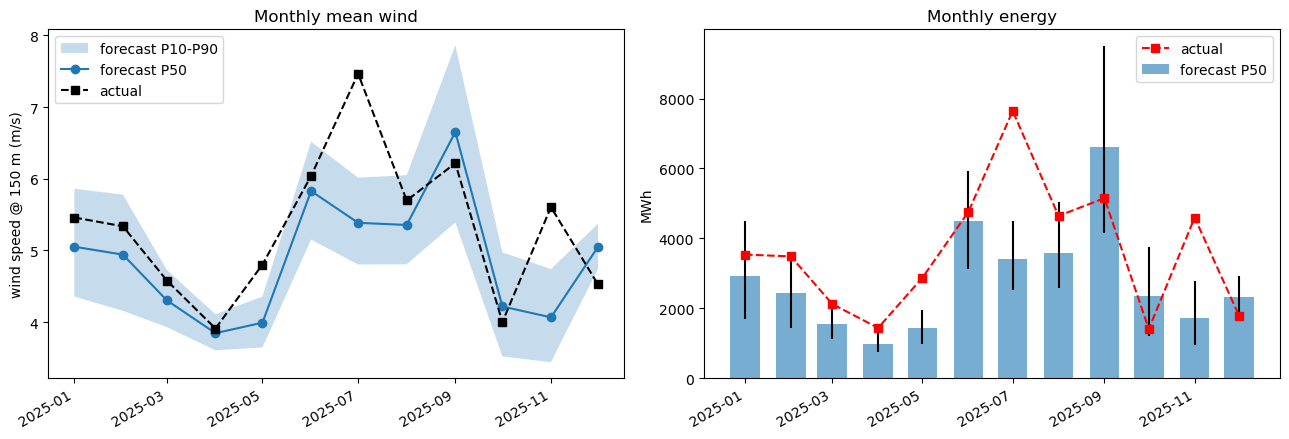

Save: 013054_20260917_075748/verify_scatter.png


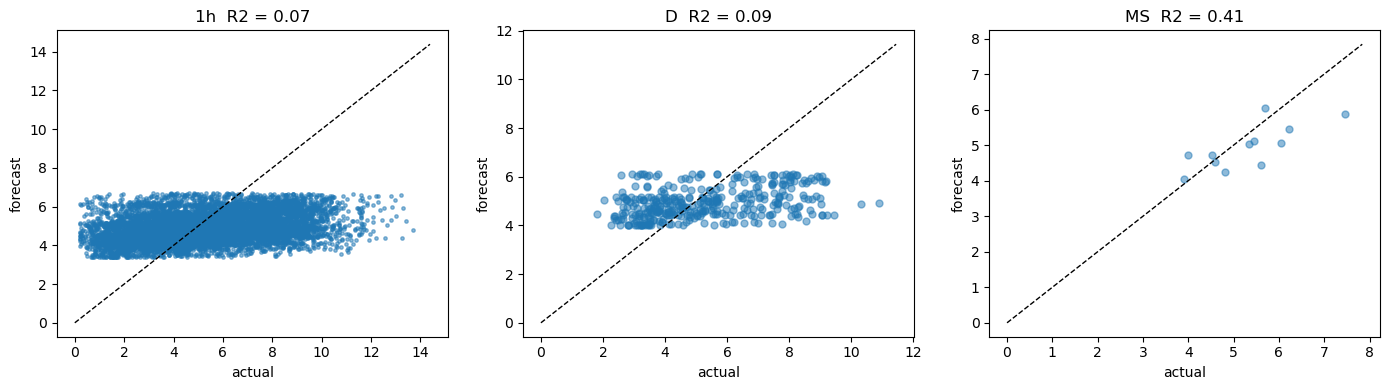

In [19]:
forecast_monthly = outputs["MS"]
fig, ax = plt.subplots(1, 2, figsize = (13, 4.5))

ax[0].fill_between(forecast_monthly.index, forecast_monthly["windspeed_mean_p10"], forecast_monthly["windspeed_mean_p90"], alpha = .25, label = "forecast P10-P90")
ax[0].plot(forecast_monthly.index, forecast_monthly["windspeed_mean_p50"], "o-", label = "forecast P50")
if VERIFIED:
    ax[0].plot(monthly.index, monthly["ws_real"], "s--k", label = "actual")
ax[0].set_ylabel(f"wind speed @ {HUB_HEIGHT} m (m/s)")
ax[0].set_title("Monthly mean wind")
ax[0].legend()

ax[1].bar(forecast_monthly.index, forecast_monthly["energy_mwh_p50"], width = 20, alpha = .6, label = "forecast P50")
ax[1].errorbar(forecast_monthly.index, forecast_monthly["energy_mwh_p50"], yerr = [forecast_monthly["energy_mwh_p50"] - forecast_monthly["energy_mwh_p10"], forecast_monthly["energy_mwh_p90"] - forecast_monthly["energy_mwh_p50"]], fmt = "none", ecolor = "k")
if VERIFIED:
    ax[1].plot(monthly.index, monthly["mwh_real"], "s--r", label = "actual")
ax[1].set_ylabel("MWh")
ax[1].set_title("Monthly energy")
ax[1].legend()

fig.autofmt_xdate()
plt.tight_layout()
data_io.save_image(fig, "forecast_monthly")
plt.show()

if VERIFIED:
    fig, ax = plt.subplots(1, 3, figsize = (14, 4))
    for axis, freq in zip(ax, ("1h", "D", "MS")):
        pair = pd.concat({"real": actual.resample(freq).mean(), "pred": point.resample(freq).mean()}, axis = 1, sort = True).dropna()
        axis.scatter(pair["real"], pair["pred"], s = 6 if freq == "1h" else 25, alpha = .5)
        lim = [0, pair.max().max() * 1.05]
        axis.plot(lim, lim, "k--", lw = 1)
        axis.set_title(f"{freq}  R2 = {scores.loc[freq, 'R2']:.2f}")
        axis.set_xlabel("actual")
        axis.set_ylabel("forecast")
    plt.tight_layout()
    data_io.save_image(fig, "verify_scatter")
    plt.show()

## CELL 8 - บันทึก metadata เตรียมเป็น API

In [21]:
meta = {
    "site": SITE["station_code"], 
    "valid_from": START, 
    "valid_to": END, 
    "height_m": HUB_HEIGHT,
    "method": f"fourier+{config.FORECAST['level_source']}+analog_blocks",
    "raw_forecast_file": RAW_FORECAST_FILE.name,
    "trained_on": state["trained_on"], 
    "data_version": DATA_VERSION,
    "alpha": ALPHA, 
    "air_density": AIR_DENSITY, 
    "interannual_variability": state["interannual_variability"], 
    "ensemble": config.FORECAST["ensemble"],
    "turbine": energy.DEFAULT_TURBINE,
    "verification": ({
        "against": ACTUAL_FILE, 
        "scores": scores.round(4).to_dict("index"),
        "in_band_pct": float(monthly["in_band"].mean() * 100)} if VERIFIED else {"status": "pending"}),
    "limits": {"timestamp_level_valid": False},
}
(data_io.run_dir() / "forecast_meta.json").write_text(json.dumps(meta, indent = 2, ensure_ascii = False, default = str), encoding = "utf-8")
print(f"Result: {data_io.run_dir()}")

Result: /home/jovyan/project/data/outputs/013054_20260917_075748
